In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import itertools
from datetime import datetime
try:
    import winsound
except:
    print("No beep")

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import metrics
from sklearn.feature_selection import SelectKBest

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from scipy.stats import loguniform, uniform

from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

from joblib import dump, load

In [2]:
# Utility functions
def plot_confusion_matrix(cm, classes,
                          normalize=True,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be changed.
    """

    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()


def eval_pipeline(pipe, name, normalize_cm=True):

    # Hard predictions at the model's default threshold 0.5
    y_pred = pipe.predict(X_te)

    # Per-class precision/recall/F1 plus macro/weighted averages
    print(f"\n=== {name} (best params) ===")
    print(metrics.classification_report(y_te, y_pred, digits=3))

    # Confusion matrix in counts for a concrete error breakdown
    cm = metrics.confusion_matrix(y_te, y_pred)
    print("Confusion matrix (counts):\n", cm)

    # Your helper draws counts or normalized CM depending on normalize_cm
    # Label order should match your y encoding: 0 = 'No diabetes', 1 = 'Diabetes'
    plot_confusion_matrix(cm, ['No diabetes','Diabetes'], normalize_cm)

    # ---- Threshold-independent metrics (use continuous scores) ----
    # Prefer probabilities if available; otherwise fall back to decision_function
    if hasattr(pipe.named_steps["model"], "predict_proba"):
        scores = pipe.predict_proba(X_te)[:, 1]   # P(y=1 | x)
    elif hasattr(pipe.named_steps["model"], "decision_function"):
        scores = pipe.decision_function(X_te)     # larger => more positive
    else:
        # Some estimators expose neither; gracefully skip AUCs
        print("Estimator has neither predict_proba nor decision_function; skipping AUCs.")
        return

    # ROC-AUC: ranking quality vs. FPR; PR-AUC (Average Precision): better for imbalance
    print(f"ROC-AUC: {metrics.roc_auc_score(y_te, scores):.3f}")
    print(f"PR-AUC : {metrics.average_precision_score(y_te, scores):.3f}")



def start_timer():
    global start_time
    start_time = datetime.now()
    print('Start time: ', start_time.strftime('%H:%M:%S'))

def end_timer():
    end_time = datetime.now()
    print('End time: ', end_time.strftime('%H:%M:%S'))
    runtime = end_time - start_time
    print('Runtime: ', runtime,'\n')

def beep_when_done():
    duration = 300  # milliseconds
    freq = 440  # Hz
    try:
        winsound.Beep(freq, duration)
    except:
        print("Beep! (Sound not working)")


In [3]:
data1_filename = "diabetes_binary_health_indicators_BRFSS2015.csv"
df1 = pd.read_csv(data1_filename)

In [4]:
# ---- Target/feature split ----
# Diabetes_binary is already 0/1; cast to int to avoid bool dtype surprises downstream.
y = df1["Diabetes_binary"].astype(int)
X = df1.drop(columns=["Diabetes_binary"])

binary_cols = [c for c in X.columns if set(pd.unique(X[c].dropna())) <= {0, 1}]
numeric_cols = [c for c in X.columns if c not in binary_cols]

# Ensure binary features are ints (not bools/floats), which keeps them 0/1 through the pipeline.
for c in binary_cols:
    X[c] = X[c].astype(int)

# ---- Hold-out split ----
# Stratified split preserves the positive rate (~class imbalance) in both train and test.
# random_state for reproducibility; keep this consistent across experiments.
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



# ---- Preprocessing pipeline ----
# Scale only the continuous features (helps linear/SGD solvers); pass binary 0/1 through unchanged.
# 'remainder="drop"' ensures only specified columns flow downstream, preventing accidental leakage.
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("bin", "passthrough", binary_cols),
    ],
    remainder="drop",
)

# ---- Cross-validation plan ----
# StratifiedKFold maintains class proportions in each fold—crucial for stable metrics on imbalanced data.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# ---- Scoring choice ----
# Default scoring method going forward.
# Options: 'f1', 'average_precision', ‘roc_auc’, 'fbeta', 'recall'
# fbeta = metrics.make_scorer(metrics.fbeta_score, beta=2.0)
scoring = 'f1'

Start time:  23:45:50
LogReg best CV score [f1]: 0.443
LogReg best params: {'model__solver': 'sag', 'model__penalty': 'l2', 'model__class_weight': 'balanced', 'model__C': np.float64(0.004124626382901352)}

=== Logistic Regression (tuned) (best params) ===
              precision    recall  f1-score   support

           0      0.950     0.727     0.824     43667
           1      0.311     0.762     0.442      7069

    accuracy                          0.732     50736
   macro avg      0.630     0.744     0.633     50736
weighted avg      0.861     0.732     0.770     50736

Confusion matrix (counts):
 [[31749 11918]
 [ 1685  5384]]


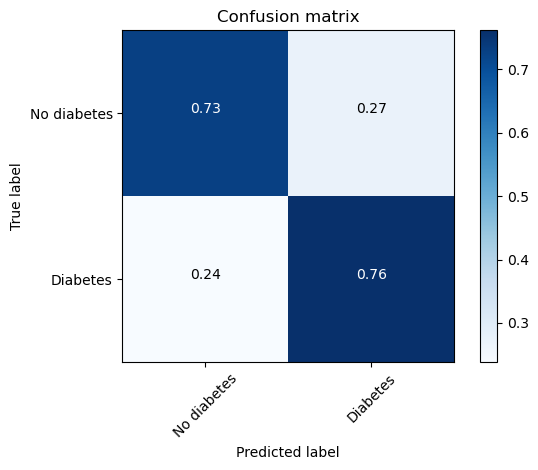

ROC-AUC: 0.820
PR-AUC : 0.392
End time:  23:46:33
Runtime:  0:00:43.223325 



In [5]:
# Logistic Regression - Stochastic Average Gradient Descent
# LogisticRegression 'sag'

start_timer()

logreg_base = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=2000))
])

# Candidate C values on a log scale (0.001 .. 10). Wider coverage is usually better than linear steps.
log_C = list(np.logspace(-3, 3, 40))

# Use a *list of dicts* to restrict to valid solver/penalty combos:
#   - liblinear supports L1/L2; fast for small/medium tabular data
#   - newton-cholesky supports L2
# Class weight is fixed to "balanced" here to keep recall higher at default threshold.
logreg_param_distributions = {
    "model__solver": ["sag"],
    "model__penalty": ["l2"],
    "model__C": log_C,
    "model__class_weight": ["balanced"]
}

# RandomizedSearchCV samples parameter settings at random; great when the space is large.
# - scoring comes from your earlier choice (e.g., "recall", "f1", or a custom F-beta).
# - refit=True means the best model (by 'scoring') is retrained on the full training set.
# - n_jobs=-1 uses all CPU cores.
logreg_rs = RandomizedSearchCV(
    estimator=logreg_base,
    param_distributions=logreg_param_distributions,
    n_iter=20,                 # increase for a wider search; reduce if runtime is long
    scoring=scoring,           # IMPORTANT: ensure this matches objective (e.g., "recall" or "f1")
    cv=cv,
    n_jobs=-1,
    refit=True,
    random_state=42,
    verbose=0
)

# Fit on training fold data only; preprocessing occurs within each CV split properly.
logreg_rs.fit(X_tr, y_tr)


label = (scoring if isinstance(scoring, str)
         else (logreg_rs.refit if isinstance(scoring, dict)
               else getattr(scoring, "_score_func", scoring).__name__))
print(f"LogReg best CV score [{label}]: {logreg_rs.best_score_:.3f}")
print("LogReg best params:", logreg_rs.best_params_)

# Evaluate the *refit* best pipeline on the held-out test set (true generalization check).
eval_pipeline(logreg_rs.best_estimator_, "Logistic Regression (tuned)")

end_timer()
beep_when_done()

In [15]:
dump(logreg_rs, 'logreg_rs.joblib')

# Later, to reload:
# logreg_rs = load('logreg_rs.joblib'

['logreg_rs.joblib']

Start time:  23:46:34
SVC (undersampled, SKB) — best CV score: 0.4361923831953448
SVC (undersampled, SKB) — best params: {'select__k': 16, 'model__kernel': 'rbf', 'model__gamma': np.float64(0.001082636733874054), 'model__C': np.float64(3.039195382313198)}

=== svc_rs (best params) ===
              precision    recall  f1-score   support

           0      0.954     0.699     0.807     43667
           1      0.299     0.792     0.434      7069

    accuracy                          0.712     50736
   macro avg      0.626     0.746     0.620     50736
weighted avg      0.863     0.712     0.755     50736

Confusion matrix (counts):
 [[30527 13140]
 [ 1470  5599]]


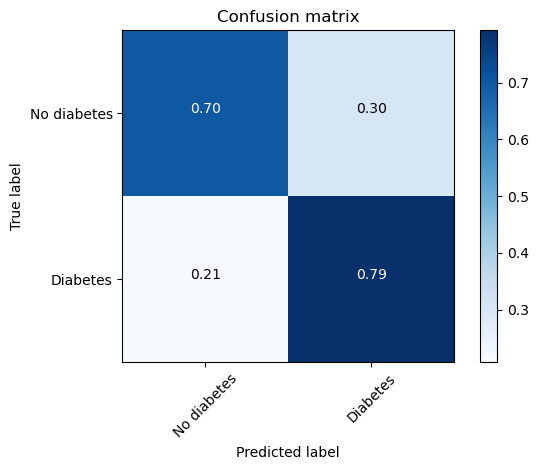

ROC-AUC: 0.821
PR-AUC : 0.404
End time:  02:51:19
Runtime:  3:04:44.816479 



In [6]:
# === SVC (undersampled, SelectKBest) with cross-validation ===

start_timer()

svc_base = ImbPipeline([
    ("prep", preprocess),
    ("under", RandomUnderSampler(sampling_strategy="auto", random_state=42)),
    ("select", SelectKBest(k=10)),
    ("model", SVC(kernel="rbf"))
])

svc_param_dist = {
    "model__kernel": ["rbf"],
    "model__C": np.logspace(-2, 2, 30),
    "model__gamma": np.logspace(-4, 1, 30),   # used only for rbf
    "select__k": [8, 10, 12, 14, 16],    # tune how many features to keep
}


svc_rs = RandomizedSearchCV(
    estimator=svc_base,
    param_distributions=svc_param_dist,
    n_iter=40,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    random_state=42,
    refit=True,
    verbose=0,
)

svc_rs.fit(X_tr, y_tr)

print("SVC (undersampled, SKB) — best CV score:", svc_rs.best_score_)
print("SVC (undersampled, SKB) — best params:", svc_rs.best_params_)

eval_pipeline(svc_rs.best_estimator_, name="svc_rs")

end_timer(); beep_when_done()

In [17]:
dump(svc_rs, 'svc_rs.joblib')

['svc_rs.joblib']

In [7]:
best = svc_rs.best_estimator_
selector = best.named_steps["select"]
prep = best.named_steps["prep"]

# boolean mask of kept features
mask = selector.get_support()

# Try to get human-readable feature names from your preprocessor
feature_names = None
try:
    # Newer sklearn usually works without args
    feature_names = prep.get_feature_names_out()
except Exception:
    # Older versions may need original column names (if X_tr is a DataFrame)
    try:
        feature_names = prep.get_feature_names_out(
            input_features=getattr(X_tr, "columns", None)
        )
    except Exception:
        pass

# Fallback: generic names if we couldn't resolve real names
if feature_names is None:
    feature_names = np.array([f"feat_{i}" for i in range(mask.shape[0])])

feature_names = np.asarray(feature_names)
selected_names = feature_names[mask]

# Pair with scores (and p-values if available)
scores = getattr(selector, "scores_", None)
pvals = getattr(selector, "pvalues_", None)

if scores is not None:
    sel_scores = scores[mask]
    order = np.argsort(sel_scores)[::-1]  # sort by score, desc
    print("Top-k selected features (by SelectKBest):")
    for i in order:
        name = selected_names[i]
        sc = sel_scores[i]
        if pvals is not None:
            pv = pvals[mask][i]
            print(f"  {name}: score={sc:.4g}, p={pv:.3g}")
        else:
            print(f"  {name}: score={sc:.4g}")
else:
    print("Selected features:")
    for n in selected_names:
        print(" ", n)

Top-k selected features (by SelectKBest):
  num__GenHlth: score=1.131e+04, p=0
  bin__HighBP: score=9558, p=0
  bin__HighChol: score=5142, p=0
  num__BMI: score=5122, p=0
  num__Age: score=4625, p=0
  bin__DiffWalk: score=4517, p=0
  num__Income: score=3075, p=0
  num__PhysHlth: score=2736, p=0
  bin__HeartDiseaseorAttack: score=2613, p=0
  num__Education: score=1711, p=0
  bin__PhysActivity: score=1548, p=0
  bin__Stroke: score=922.9, p=4.29e-201
  bin__CholCheck: score=786.4, p=7.48e-172
  bin__HvyAlcoholConsump: score=511.9, p=7.97e-113
  bin__Smoker: score=487.8, p=1.22e-107
  num__MentHlth: score=436.6, p=1.4e-96


Start time:  02:51:19
Fitting 5 folds for each of 40 candidates, totalling 200 fits
LinearSVC (RandomizedSearchCV)
Best params: {'model__C': np.float64(7.2866537374910445), 'model__class_weight': 'balanced', 'model__loss': 'hinge', 'model__tol': np.float64(0.004138040112561018)}
Best mean CV score: 0.43599238635049586

=== LinearSVC (RS) (best params) ===
              precision    recall  f1-score   support

           0      0.954     0.703     0.809     43667
           1      0.301     0.789     0.435      7069

    accuracy                          0.715     50736
   macro avg      0.627     0.746     0.622     50736
weighted avg      0.863     0.715     0.757     50736

Confusion matrix (counts):
 [[30697 12970]
 [ 1492  5577]]


C:\Users\conte\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


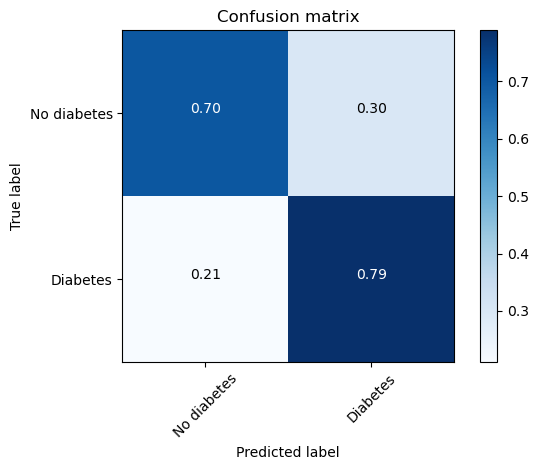

ROC-AUC: 0.819
PR-AUC : 0.393
End time:  02:58:07
Runtime:  0:06:48.027012 



In [8]:
# ------------ LinearSVC -------------

start_timer()

# Pipeline: preprocess -> LinearSVC
# NOTE: step is named "model" so eval_pipeline() finds it
svc_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearSVC(class_weight="balanced", max_iter=100000))
])

# Convergence-friendly search space:
# - Prefer squared_hinge (lets us use dual=False, which often converges better when n_samples >> n_features)
# - Allow both dual settings; the CV will pick what works best
# - Narrow C to a saner band and use a slightly looser tol range
param_distributions = {
    "model__C":   loguniform(1e-3, 1e1),
    "model__tol": loguniform(1e-4, 1e-2),
    "model__loss": ["hinge"],
    "model__class_weight": ["balanced"]
}

lsvc_rs = RandomizedSearchCV(
    estimator=svc_pipe,
    param_distributions=param_distributions,
    n_iter=40,
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    random_state=42,
    refit=True,
    verbose=1
)

lsvc_rs.fit(X_tr, y_tr)

print("LinearSVC (RandomizedSearchCV)")
print("Best params:", lsvc_rs.best_params_)
print("Best mean CV score:", lsvc_rs.best_score_)

# Evaluate on your held-out test split using the shared helper
eval_pipeline(lsvc_rs.best_estimator_, name="LinearSVC (RS)")

end_timer(); beep_when_done()

In [19]:
dump(lsvc_rs, 'lsvc_rs.joblib')

['lsvc_rs.joblib']

Start time:  11:45:42
Fitting 5 folds for each of 15 candidates, totalling 75 fits
LDA (lsqr + numeric shrinkage) — RandomizedSearchCV
Best params: {'model__shrinkage': np.float64(0.8661761457749352), 'model__solver': 'lsqr'}
Best mean CV score: 0.4137995816703424

=== LDA lsqr (RS) (best params) ===
              precision    recall  f1-score   support

           0      0.910     0.864     0.887     43667
           1      0.362     0.475     0.411      7069

    accuracy                          0.810     50736
   macro avg      0.636     0.670     0.649     50736
weighted avg      0.834     0.810     0.820     50736

Confusion matrix (counts):
 [[37736  5931]
 [ 3711  3358]]


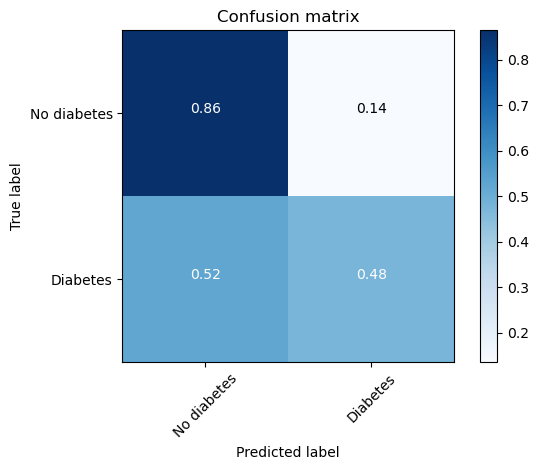

ROC-AUC: 0.797
PR-AUC : 0.357
End time:  11:45:54
Runtime:  0:00:11.955183 



In [11]:
# --- Linear Discriminant Analysis (lsqr, numeric shrinkage only) ---

start_timer()

# Pipeline: preprocess -> LDA  (step named "model" so eval_pipeline works)
lda_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearDiscriminantAnalysis())
])

# Only least-squares solver with numeric shrinkage in [0, 1]
lsqr_num_dist = {
    "model__solver": ["lsqr"],
    "model__shrinkage": uniform(0.0, 1.0),
}

lda_rs_lsqr = RandomizedSearchCV(
    estimator=lda_pipe,
    param_distributions=lsqr_num_dist,
    n_iter=15,                 # raise for deeper search
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    random_state=42,
    refit=True,
    verbose=1,
    error_score=np.nan,
)

lda_rs_lsqr.fit(X_tr, y_tr)

print("LDA (lsqr + numeric shrinkage) — RandomizedSearchCV")
print("Best params:", lda_rs_lsqr.best_params_)
print("Best mean CV score:", lda_rs_lsqr.best_score_)

# Evaluate on your held-out test split
eval_pipeline(lda_rs_lsqr.best_estimator_, name="LDA lsqr (RS)")

end_timer(); beep_when_done()


In [21]:
dump(lda_rs_lsqr, 'lda_rs_lsqr.joblib')

['lda_rs_lsqr.joblib']